In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [13]:
#load the dataset
df = pd.read_csv('customer_data_records.csv')
# Display the first few rows of the dataset
print(df.head())


   CustomerID  Annual Income (k$)  Spending Score (1-100)
0           1                 117                      20
1           2                 107                      59
2           3                  29                      36
3           4                 121                      19
4           5                  86                      90


In [14]:
#select the features for clustering
x = df[['Annual Income (k$)', 'Spending Score (1-100)']]


In [15]:
#apply KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(x)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [16]:
#add cluster lebels to dataset
df['cluster'] = kmeans.labels_
print(df)

     CustomerID  Annual Income (k$)  Spending Score (1-100)  cluster
0             1                 117                      20        1
1             2                 107                      59        1
2             3                  29                      36        0
3             4                 121                      19        1
4             5                  86                      90        0
..          ...                 ...                     ...      ...
169         170                 111                      76        1
170         171                 138                      87        1
171         172                  84                      15        0
172         173                 107                      92        1
173         174                  17                      98        0

[174 rows x 4 columns]


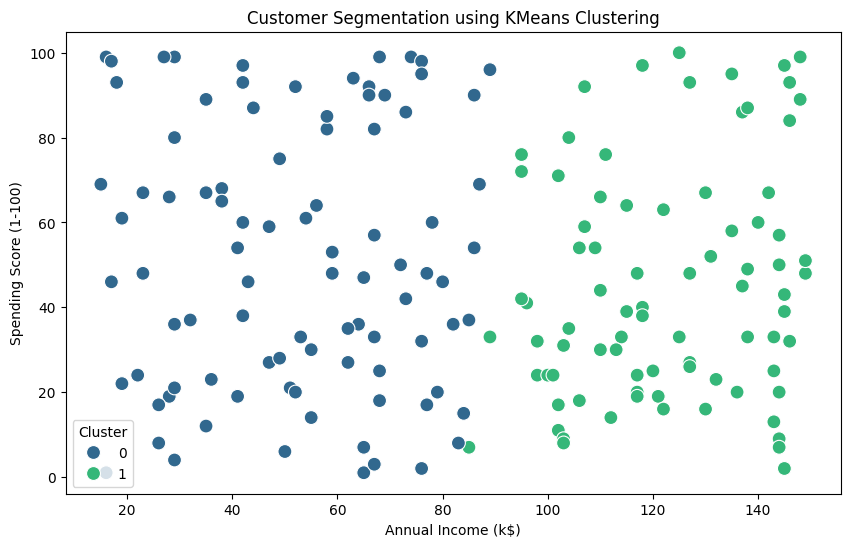

In [ ]:
#visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='cluster', palette='viridis', s=100)
plt.title('Customer clustering based on Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')


In [18]:
#cluster 2
#selct features for cluster 2
x2 = df[df['cluster'] == 1][['Annual Income (k$)', 'Spending Score (1-100)']]

In [19]:
#apply KMeans clustering for cluster 2
kmeans2 = KMeans(n_clusters=2, random_state=0)
kmeans2.fit(x2)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [20]:
#add cluster labels to dataset for cluster 2
df.loc[df['cluster'] == 1, 'sub_cluster'] = kmeans2.labels_
print(df[df['cluster'] == 1])


     CustomerID  Annual Income (k$)  Spending Score (1-100)  cluster  \
0             1                 117                      20        1   
1             2                 107                      59        1   
3             4                 121                      19        1   
6             7                 117                      19        1   
7             8                 136                      20        1   
..          ...                 ...                     ...      ...   
167         168                 130                      16        1   
168         169                 112                      14        1   
169         170                 111                      76        1   
170         171                 138                      87        1   
172         173                 107                      92        1   

     sub_cluster  
0            1.0  
1            0.0  
3            1.0  
6            1.0  
7            1.0  
..           ...  
16

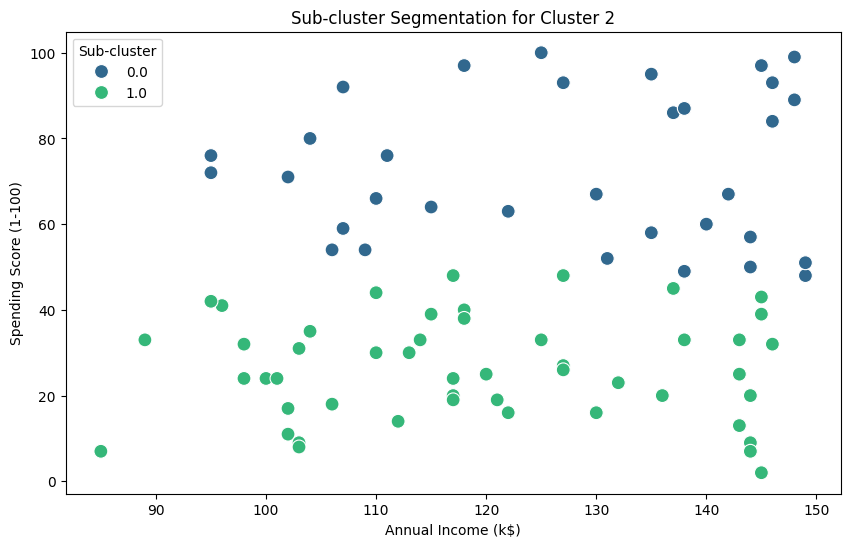

In [22]:
#visualize the cluster2
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['cluster'] == 1], x='Annual Income (k$)', y='Spending Score (1-100)', hue='sub_cluster', palette='viridis', s=100)
plt.title('Sub-cluster Segmentation for Cluster 2')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Sub-cluster')

